Exploratory data analysis (EDA) is a crucial component of data science which allows you to understand the basics of what your data looks like and what kinds of questions might be answered. For this task, we are going to clean, sanitise and explore our data. Using the automobile dataset, complete the steps outlined in this notebook by writing code in the cells.

In [1]:
# Import the libraries required for data analysis and visualisation

import numpy as np
import pandas as pd
import seaborn as sns

from datetime import datetime
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
# Load the automobile dataset into a pandas DataFrame.
# The question mark symbol is treated as a missing value.

try:
    automobiles_df = pd.read_csv(
        "automobile.txt",
        na_values="?"
    )

    print("The automobile dataset was loaded successfully.")

except FileNotFoundError:
    print(
        "Error: automobile.txt was not found. "
        "Make sure it is in the same folder as the notebook."
    )
# Display the first five rows of the dataset

automobiles_df.head()

The automobile dataset was loaded successfully.


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


### Data Cleansing
#### Clean the data

Identify columns that are redundant or unnecessary. It is always easier to make your decisions based on data which is relevant and concise. Remove the following columns `['normalized-losses', 'symboling']` from the data set as they will not be used in the analysis.

In [3]:
# Display the dimensions of the original dataset

print("Original number of rows:", automobiles_df.shape[0])
print("Original number of columns:", automobiles_df.shape[1])

# Display the names of all columns before cleaning

print("Columns before cleaning:")
print(automobiles_df.columns.tolist())

# Remove redundant columns that are not required for the analysis

columns_to_remove = [
    "normalized-losses",
    "symboling"
]

automobiles_df = automobiles_df.drop(
    columns=columns_to_remove
)
# Confirm that the unnecessary columns were removed

print("Number of columns after removal:", automobiles_df.shape[1])
print("\nColumns after cleaning:")
print(automobiles_df.columns.tolist())

Original number of rows: 205
Original number of columns: 26
Columns before cleaning:
['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style', 'drive-wheels', 'engine-location', 'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type', 'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price']
Number of columns after removal: 24

Columns after cleaning:
['make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style', 'drive-wheels', 'engine-location', 'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type', 'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price']


#### Remove any duplicate rows

In [4]:
# Count duplicate rows before cleaning

duplicate_count = automobiles_df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

# Remove duplicate rows from the dataset

automobiles_df = automobiles_df.drop_duplicates()
# Verify that duplicate rows were removed

remaining_duplicates = automobiles_df.duplicated().sum()

print(
    "Number of duplicate rows after cleaning:",
    remaining_duplicates
)

Number of duplicate rows: 0
Number of duplicate rows after cleaning: 0


#### Remove rows with missing data

Some automobiles in the database have missing values which implies that their values have not been recorded or some information is missing. Discard such entries from the dataframe.

In [5]:
# Count missing values in each column before cleaning

missing_values_before = automobiles_df.isnull().sum()

print("Missing values before cleaning:")
print(missing_values_before)

# Store the number of rows before removing missing data

rows_before_missing_removal = automobiles_df.shape[0]

print(
    "Number of rows before removing missing values:",
    rows_before_missing_removal
)
# Remove every row containing one or more missing values

automobiles_df = automobiles_df.dropna()

# Calculate how many rows were removed

rows_after_missing_removal = automobiles_df.shape[0]

rows_removed = (
    rows_before_missing_removal
    - rows_after_missing_removal
)

print(
    "Number of rows removed:",
    rows_removed
)

print(
    "Number of rows remaining:",
    rows_after_missing_removal
)
# Verify that no missing values remain

missing_values_after = automobiles_df.isnull().sum()

print("Missing values after cleaning:")
print(missing_values_after)

Missing values before cleaning:
make                 0
fuel-type            0
aspiration           0
num-of-doors         2
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 4
stroke               4
compression-ratio    0
horsepower           2
peak-rpm             2
city-mpg             0
highway-mpg          0
price                4
dtype: int64
Number of rows before removing missing values: 205
Number of rows removed: 12
Number of rows remaining: 193
Missing values after cleaning:
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight

Change columns with numerical data column to an integer data type using numpy’s `int64` method.

In [6]:
# Display data types before conversion

print("Data types before conversion:")
print(
    automobiles_df[
        ["horsepower", "peak-rpm", "price"]
    ].dtypes
)
# Convert selected numerical columns to the NumPy int64 data type

integer_columns = [
    "horsepower",
    "peak-rpm",
    "price"
]

for column in integer_columns:
    automobiles_df[column] = (
        automobiles_df[column]
        .astype(np.int64)
    )

# Confirm that the selected columns were converted successfully

print("Data types after conversion:")
print(
    automobiles_df[
        integer_columns
    ].dtypes
)
# Display a summary of the cleaned dataset

automobiles_df.info()

Data types before conversion:
horsepower    float64
peak-rpm      float64
price         float64
dtype: object
Data types after conversion:
horsepower    int64
peak-rpm      int64
price         int64
dtype: object
<class 'pandas.DataFrame'>
Index: 193 entries, 0 to 204
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   make               193 non-null    str    
 1   fuel-type          193 non-null    str    
 2   aspiration         193 non-null    str    
 3   num-of-doors       193 non-null    str    
 4   body-style         193 non-null    str    
 5   drive-wheels       193 non-null    str    
 6   engine-location    193 non-null    str    
 7   wheel-base         193 non-null    float64
 8   length             193 non-null    float64
 9   width              193 non-null    float64
 10  height             193 non-null    float64
 11  curb-weight        193 non-null    int64  
 12  engine-type        19

### Finding Certain Categories
Locate all automobiles in the "hatchback" genre.

In [7]:
# Create a DataFrame containing only hatchback automobiles

hatchback_cars = automobiles_df[
    automobiles_df["body-style"] == "hatchback"
].copy()
# Display the number of hatchback vehicles found

print(
    "Number of hatchback vehicles:",
    hatchback_cars.shape[0]
)
# Display selected details about hatchback vehicles

hatchback_cars[
    [
        "make",
        "body-style",
        "horsepower",
        "city-mpg",
        "highway-mpg",
        "price"
    ]
].head(10)

Number of hatchback vehicles: 63


,make,body-style,horsepower,city-mpg,highway-mpg,price
2,alfa-romero,hatchback,154,19,26,16500
18,chevrolet,hatchback,48,47,53,5151
19,chevrolet,hatchback,70,38,43,6295
21,dodge,hatchback,68,37,41,5572
22,dodge,hatchback,68,31,38,6377
23,dodge,hatchback,102,24,30,7957
24,dodge,hatchback,68,31,38,6229
29,dodge,hatchback,145,19,24,12964
30,honda,hatchback,58,49,54,6479
31,honda,hatchback,76,31,38,6855


### Now onto the exploration

#### Identify relationships between variables (features)

The main goal here is to identify and create relationships that can help you formulate ideas. We have defined questions to help you identify some relationships to explore.

#### Which are the 5 most expensive cars?

How do the most expensive and cheapest cars compare? Exploring the most expensive cars highlights if some moviecars are worth the money spent on them based on their fuel economy (mpg or miles per gallon)

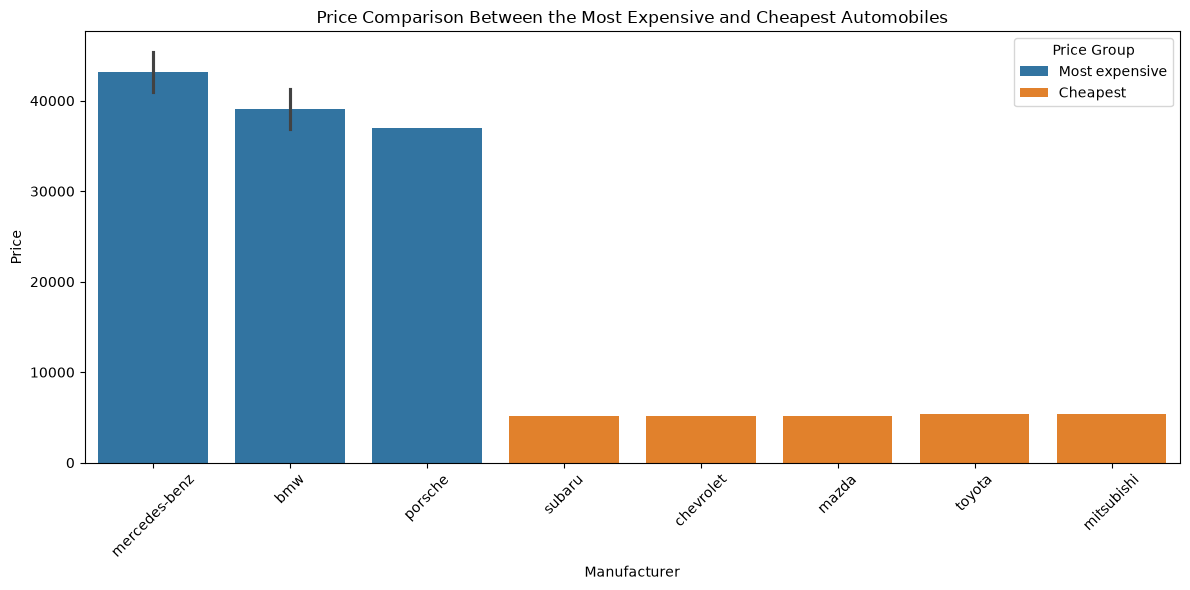

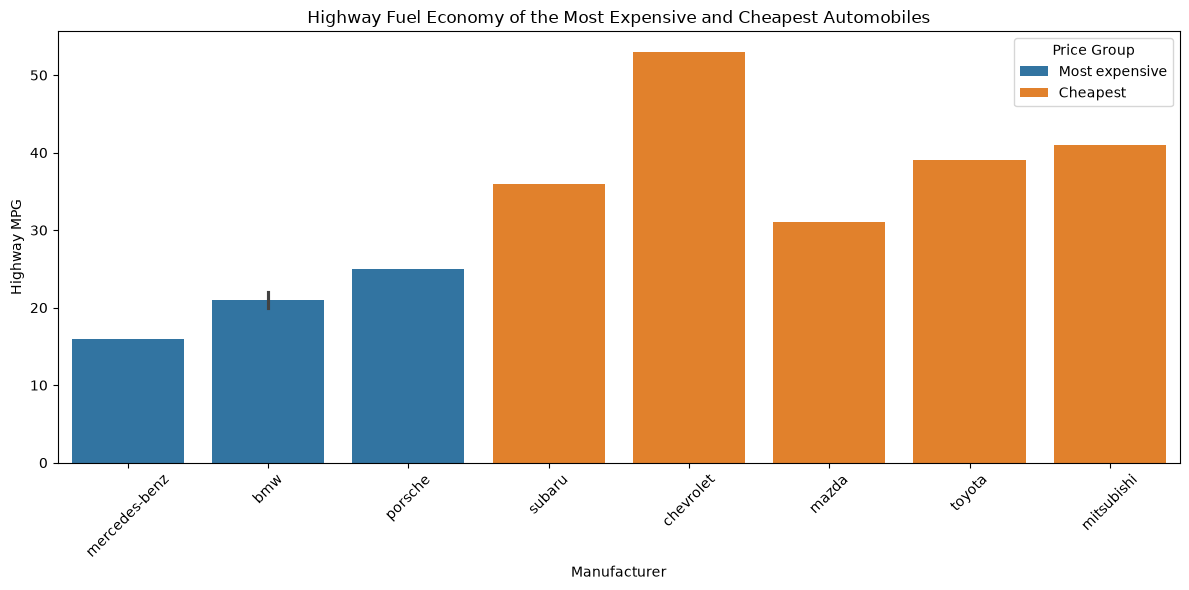

In [8]:
# Select the five most expensive automobiles

most_expensive_cars = automobiles_df.nlargest(
    5,
    "price"
)
# Display the five most expensive automobiles

most_expensive_cars[
    [
        "make",
        "body-style",
        "horsepower",
        "city-mpg",
        "highway-mpg",
        "price"
    ]
]
# Select the five cheapest automobiles for comparison

cheapest_cars = automobiles_df.nsmallest(
    5,
    "price"
)
# Display the five cheapest automobiles

cheapest_cars[
    [
        "make",
        "body-style",
        "horsepower",
        "city-mpg",
        "highway-mpg",
        "price"
    ]
]
# Combine the most expensive and cheapest cars into one DataFrame

price_comparison = pd.concat(
    [
        most_expensive_cars.assign(
            price_group="Most expensive"
        ),
        cheapest_cars.assign(
            price_group="Cheapest"
        )
    ]
)
# Create a bar chart comparing the most expensive
# and cheapest automobiles

plt.figure(figsize=(12, 6))

sns.barplot(
    data=price_comparison,
    x="make",
    y="price",
    hue="price_group"
)

plt.title(
    "Price Comparison Between the Most Expensive "
    "and Cheapest Automobiles"
)

plt.xlabel("Manufacturer")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.legend(title="Price Group")
plt.tight_layout()

plt.show()

# Compare highway fuel economy between the most
# expensive and cheapest vehicles

plt.figure(figsize=(12, 6))

sns.barplot(
    data=price_comparison,
    x="make",
    y="highway-mpg",
    hue="price_group"
)

plt.title(
    "Highway Fuel Economy of the Most Expensive "
    "and Cheapest Automobiles"
)

plt.xlabel("Manufacturer")
plt.ylabel("Highway MPG")
plt.xticks(rotation=45)
plt.legend(title="Price Group")
plt.tight_layout()

plt.show()

### Finding

The most expensive vehicles generally have larger engines and higher
horsepower, but they tend to achieve lower fuel economy than the cheapest
vehicles. This suggests that a higher price does not necessarily result in
better fuel efficiency.

#### Which manufacturer builds the most fuel efficient vehicles?

Compare the average mpg for each vehicle manufacture's vehicles and create a bar plot

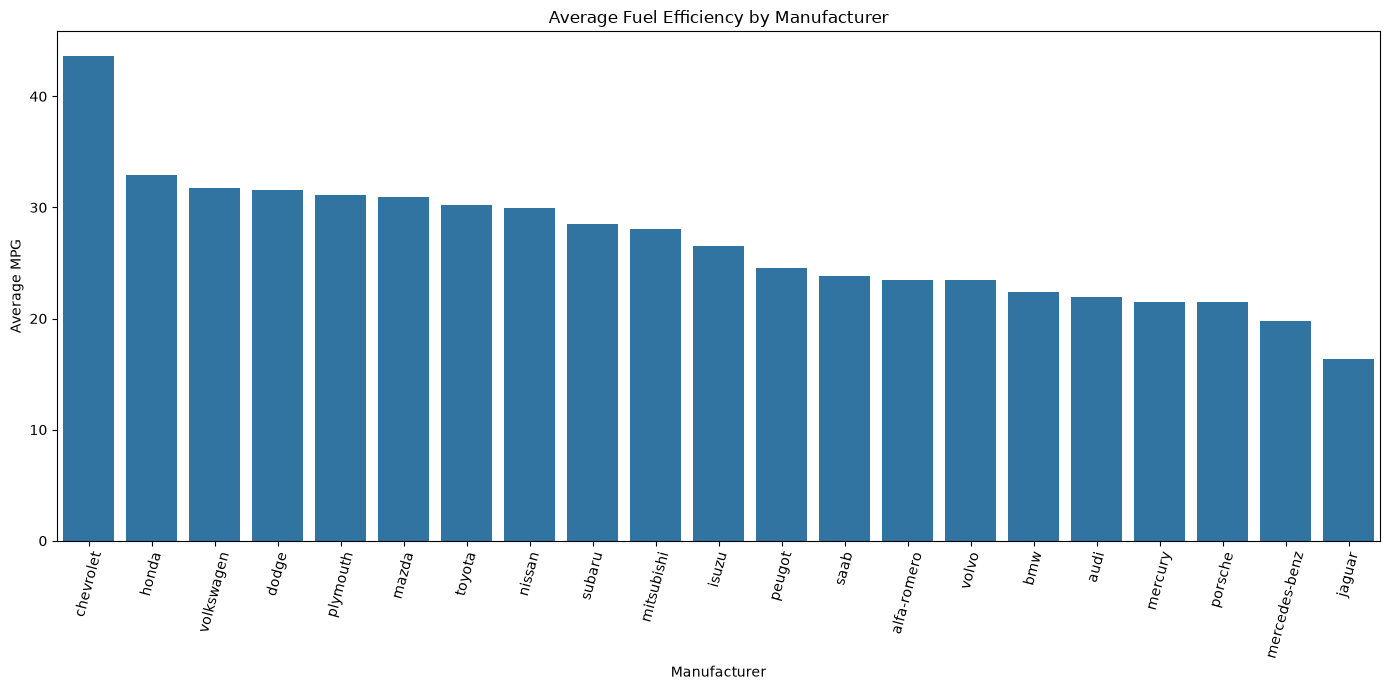

Most fuel-efficient manufacturer: chevrolet
Average MPG: 43.67


In [9]:
# Calculate the combined average MPG for each automobile

automobiles_df["average-mpg"] = (
    automobiles_df["city-mpg"]
    + automobiles_df["highway-mpg"]
) / 2

# Calculate the average fuel efficiency for each manufacturer

manufacturer_mpg = (
    automobiles_df
    .groupby("make")["average-mpg"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
# Display manufacturers ordered by average fuel efficiency

manufacturer_mpg

# Create a bar chart showing average MPG by manufacturer

plt.figure(figsize=(14, 7))

sns.barplot(
    data=manufacturer_mpg,
    x="make",
    y="average-mpg"
)

plt.title("Average Fuel Efficiency by Manufacturer")
plt.xlabel("Manufacturer")
plt.ylabel("Average MPG")
plt.xticks(rotation=75)
plt.tight_layout()

plt.show()

# Display the most fuel-efficient manufacturer

most_efficient_manufacturer = manufacturer_mpg.iloc[0]

print(
    "Most fuel-efficient manufacturer:",
    most_efficient_manufacturer["make"]
)

print(
    "Average MPG:",
    round(
        most_efficient_manufacturer["average-mpg"],
        2
    )
)


### Finding

Chevrolet has the highest average fuel
efficiency in the cleaned dataset. The result was calculated by averaging
city MPG and highway MPG for each vehicle and then grouping the results by
manufacturer.

### Which vehicles have the largest engine capacity?

Sort the dataframe based on the engine-size column.

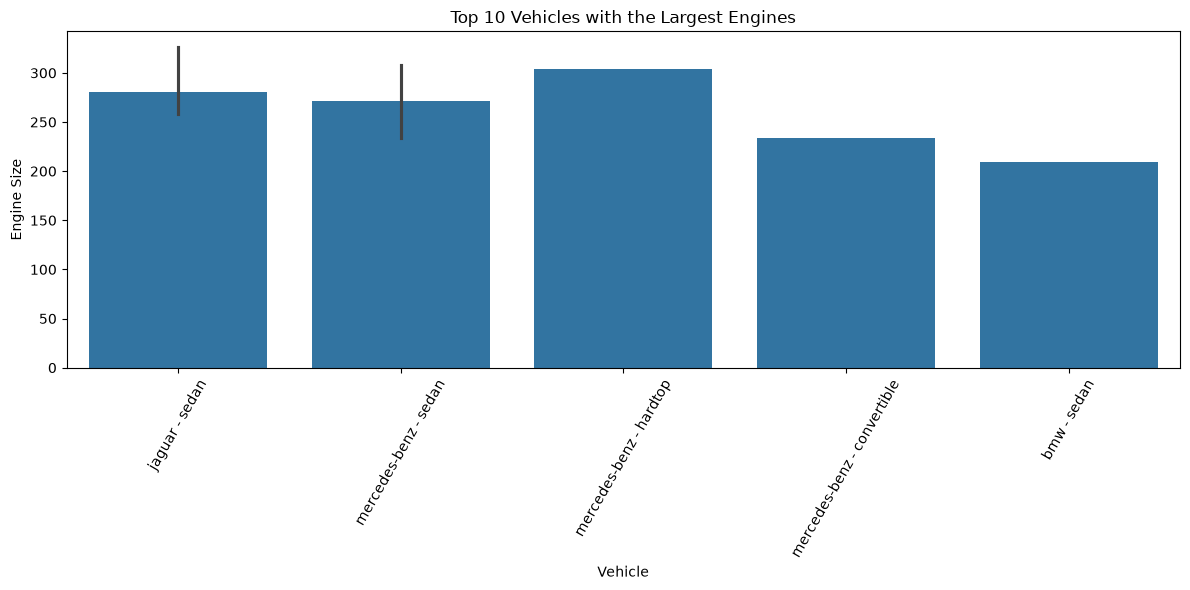

In [10]:
# Sort automobiles by engine size from largest to smallest

automobiles_by_engine_size = (
    automobiles_df
    .sort_values(
        by="engine-size",
        ascending=False
    )
)

# Display the ten vehicles with the largest engines

largest_engine_vehicles = (
    automobiles_by_engine_size
    .head(10)
)

largest_engine_vehicles[
    [
        "make",
        "body-style",
        "num-of-cylinders",
        "engine-size",
        "horsepower",
        "price"
    ]
]
# Create labels to distinguish vehicles
# from the same manufacturer

largest_engine_vehicles = (
    largest_engine_vehicles.copy()
)

largest_engine_vehicles["vehicle-label"] = (
    largest_engine_vehicles["make"]
    + " - "
    + largest_engine_vehicles["body-style"]
)

# Create a bar chart for the vehicles
# with the largest engine capacity

plt.figure(figsize=(12, 6))

sns.barplot(
    data=largest_engine_vehicles,
    x="vehicle-label",
    y="engine-size"
)

plt.title("Top 10 Vehicles with the Largest Engines")
plt.xlabel("Vehicle")
plt.ylabel("Engine Size")
plt.xticks(rotation=60)
plt.tight_layout()

plt.show()


### Finding

The vehicles with the largest engines are generally associated with luxury
or high-performance manufacturers. These vehicles also tend to have greater
horsepower and higher prices than vehicles with smaller engines.

### Which vehicle manufacturer has the most car models in the dataset

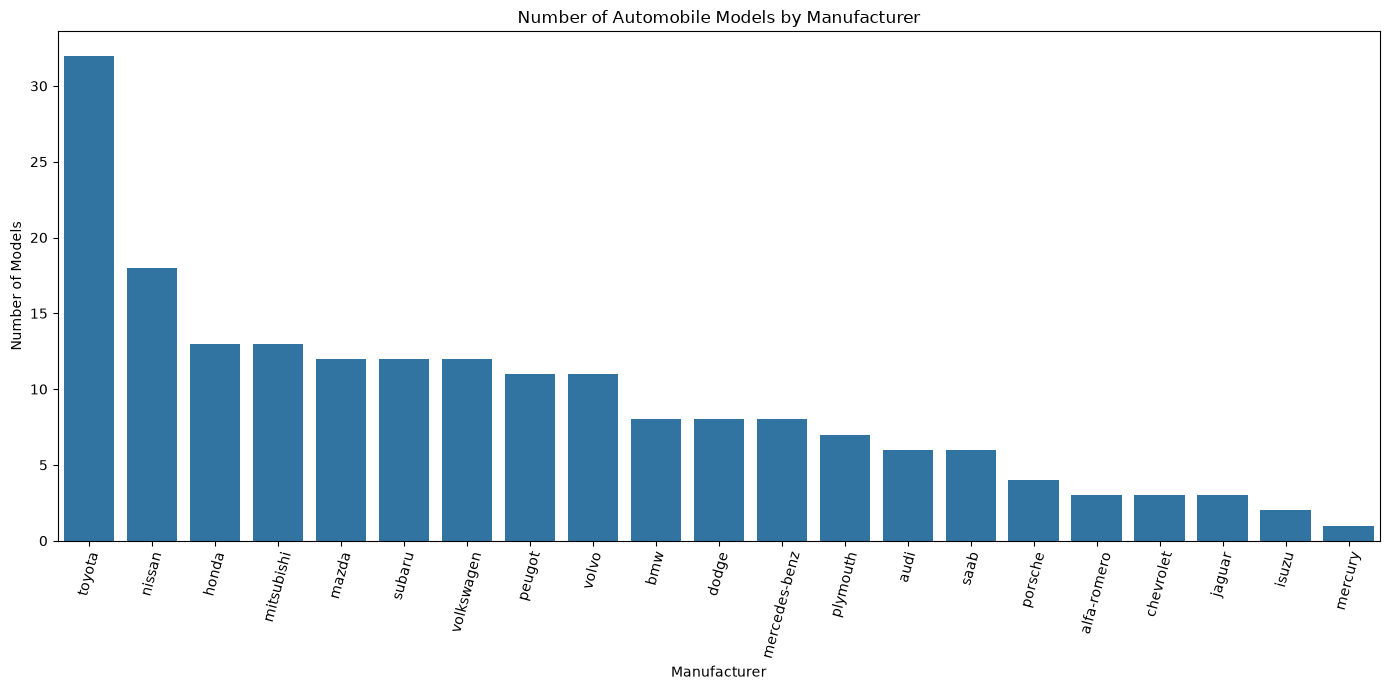

Manufacturer with the most models: toyota
Number of models: 32


In [11]:
# Count the number of vehicles recorded for each manufacturer

manufacturer_model_counts = (
    automobiles_df["make"]
    .value_counts()
    .reset_index()
)

manufacturer_model_counts.columns = [
    "manufacturer",
    "number-of-models"
]
# Display manufacturers ordered by number of models

manufacturer_model_counts
# Create a bar chart showing the number of models
# recorded for each manufacturer

plt.figure(figsize=(14, 7))

sns.barplot(
    data=manufacturer_model_counts,
    x="manufacturer",
    y="number-of-models"
)

plt.title(
    "Number of Automobile Models by Manufacturer"
)

plt.xlabel("Manufacturer")
plt.ylabel("Number of Models")
plt.xticks(rotation=75)
plt.tight_layout()

plt.show()
# Display the manufacturer with the most models

manufacturer_with_most_models = (
    manufacturer_model_counts.iloc[0]
)

print(
    "Manufacturer with the most models:",
    manufacturer_with_most_models["manufacturer"]
)

print(
    "Number of models:",
    manufacturer_with_most_models["number-of-models"]
)


### Finding

Toyota has the largest number of vehicle
entries in the cleaned dataset. This result describes representation within
this dataset and does not necessarily indicate the manufacturer's complete
real-world model range.